4. Multilayer Perceptron (MLP) — PyTorch required

    At least one hidden layer with nonlinearity (e.g., ReLU).
    Example: 784 → 256 → 128 → 10.
    Train with SGD

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
from numpy import asarray
import pandas as pd
from pathlib import Path

In [2]:
# load data
loaded = np.load("x_short_data.npz")
x_data = loaded["data"]

loaded = np.load("y_short_target.npz")
y_target = loaded["data"]

In [3]:
# normalize
x_data = x_data / 255

# images = ((images / 255.0) - 0.5) * 2  # do this according to the book

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_target, test_size=0.3, shuffle=True
)

In [5]:
def sigmoid(z):
    return 1. / (1. + np.exp(-z))

def int_to_onehot(y, num_labels):
    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1
    return ary

class NeuralNetMLP:
    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        super().__init__()

        self.num_classes = num_classes
        # hidden
        rng = np.random.RandomState(random_seed)
        self.weight_h = rng.normal(loc=0.0, scale=0.1, size=(num_hidden, num_features))
        self.bias_h = np.zeros(num_hidden)
        # output
        self.weight_out = rng.normal(loc=0.0, scale=0.1, size=(num_classes, num_hidden))
        self.bias_out = np.zeros(num_classes)
    def forward(self, x):
        # Hidden layer
        # input dim: [n_examples, n_features]
        # dot [n_hidden, n_features].T
        # output dim: [n_examples, n_hidden]
        z_h = np.dot(x, self.weight_h.T) + self.bias_h
        a_h = sigmoid(z_h)
        # Output layer
        # input dim: [n_examples, n_hidden]
        # dot [n_classes, n_hidden].T
        # output dim: [n_examples, n_classes]
        z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):
        #########################
        ### Output layer weights
        #########################
        # one-hot encoding
        y_onehot = int_to_onehot(y, self.num_classes)
        # Part 1: dLoss/dOutWeights
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/dOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## for convenient re-use
        # input/output dim: [n_examples, n_classes]
        d_loss__d_a_out = 2.*(a_out - y_onehot) / y.shape[0]
        # input/output dim: [n_examples, n_classes]
        d_a_out__d_z_out = a_out * (1. - a_out) # sigmoid derivative
        # output dim: [n_examples, n_classes]
        delta_out = d_loss__d_a_out * d_a_out__d_z_out
        # gradient for output weights
        # [n_examples, n_hidden]
        d_z_out__dw_out = a_h
        # input dim: [n_classes, n_examples]
        # dot [n_examples, n_hidden]
        # output dim: [n_classes, n_hidden]
        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)
        #################################
        # Part 2: dLoss/dHiddenWeights
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet
        # * dHiddenNet/dWeight
        # [n_classes, n_hidden]
        d_z_out__a_h = self.weight_out
        # output dim: [n_examples, n_hidden]
        d_loss__a_h = np.dot(delta_out, d_z_out__a_h)
        # [n_examples, n_hidden]
        d_a_h__d_z_h = a_h * (1.0 - a_h)  # sigmoid derivative
        # [n_examples, n_features]
        d_z_h__d_w_h = x
        # output dim: [n_hidden, n_features]
        d_loss__d_w_h = np.dot((d_loss__a_h * d_a_h__d_z_h).T, d_z_h__d_w_h)
        d_loss__d_b_h = np.sum((d_loss__a_h * d_a_h__d_z_h), axis=0)
        return (d_loss__dw_out, d_loss__db_out, d_loss__d_w_h, d_loss__d_b_h)

In [6]:
model = NeuralNetMLP(num_features=28*28, num_hidden=50, num_classes=10)

In [7]:
num_epochs = 50
minibatch_size = 100

def minibatch_generator(x, y, minibatch_size):
    indices = np.arange(x.shape[0])
    np.random.shuffle(indices)
    for start_idx in range(0, indices.shape[0] - minibatch_size + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]
        yield x[batch_idx], y[batch_idx]

for i in range(num_epochs):
    minibatch_gen = minibatch_generator(
        x_train, y_train, minibatch_size)
    for x_train_mini, y_train_mini in minibatch_gen:
        break
    break
print(x_train_mini.shape)
print(y_train_mini.shape)

(100, 784)
(100,)


In [8]:
def mse_loss(targets, probas,num_labels=10):
    onehot_targets = int_to_onehot(
        targets, num_labels=num_labels
    )
    return np.mean((onehot_targets - probas)**2)

def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets)

In [9]:
_, probas = model.forward(x_test)
mse = mse_loss(y_test, probas)
print(f'Initial validation MSE:  {mse:.1f}')

predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_test, predicted_labels)
print(f'Initial validation accuracy: {acc*100:.1f}%')

Initial validation MSE:  0.2
Initial validation accuracy: 9.3%


In [10]:
def compute_mse_and_acc(nnet, x, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(x, y, minibatch_size)
    for i, (features, targets) in enumerate(minibatch_gen):
        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)
        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()
        num_examples += targets.shape[0]
        mse += loss
    mse = mse/i
    acc = correct_pred/num_examples
    return mse, acc

In [11]:
mse, acc = compute_mse_and_acc(model, x_test, y_test)
print(f'Initial valid MSE: {mse:.1f}')
print(f'Initial valid accuracy: {acc*100:.1f}%')

Initial valid MSE: 0.3
Initial valid accuracy: 9.3%


In [12]:
def train(model, x_train, y_train, x_test, y_test, num_epochs, learning_rate=0.1):
    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []

    for e in range(num_epochs):
        # iterate over minibatches
        minibatch_gen = minibatch_generator(
        x_train, y_train, minibatch_size)
        # for x_train_mini, y_train_mini in minibatch_gen:
        #     #### Compute outputs ####
        #     a_h, a_out = model.forward(x_train_mini)
        #     #### Compute gradients ####
        #     d_loss__d_w_out, d_loss__d_b_out, \
        #     d_loss__d_w_h, d_loss__d_b_h = \
        #     model.backward(x_train_mini, a_h, a_out,
        #     y_train_mini)
        
        for x_train_mini, y_train_mini in minibatch_gen:
            a_h, a_out = model.forward(x_train_mini)
            d_w_out, d_b_out, d_w_h, d_b_h = model.backward(
                x_train_mini, a_h, a_out, y_train_mini
            )

            model.weight_h -= learning_rate * d_w_h
            model.bias_h -= learning_rate * d_b_h
            model.weight_out -= learning_rate * d_w_out
            model.bias_out -= learning_rate * d_b_out

        # Compute and log metrics here, still inside the epoch loop.

        #### Update weights ####
        # model.weight_h -= learning_rate * d_loss__d_w_h
        # model.bias_h -= learning_rate * d_loss__d_b_h
        # model.weight_out -= learning_rate * d_loss__d_w_out
        # model.bias_out -= learning_rate * d_loss__d_b_out

    #### Epoch Logging ####
    train_mse, train_acc = compute_mse_and_acc(
    model, x_train, y_train
    )
    valid_mse, valid_acc = compute_mse_and_acc(
    model, x_test, y_test
    )
    train_acc, valid_acc = train_acc*100, valid_acc*100
    epoch_train_acc.append(train_acc)
    epoch_valid_acc.append(valid_acc)
    epoch_loss.append(train_mse)
    print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
    f'| Train MSE: {train_mse:.2f} '
    f'| Train Acc: {train_acc:.2f}% '
    f'| Valid Acc: {valid_acc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc

In [13]:
np.random.seed(123) # for the training set shuffling
epoch_loss, epoch_train_acc, epoch_valid_acc = train(model, x_train, y_train, x_test, y_test,num_epochs=50, learning_rate=0.1)

Epoch: 050/050 | Train MSE: 0.02 | Train Acc: 90.64% | Valid Acc: 90.20%


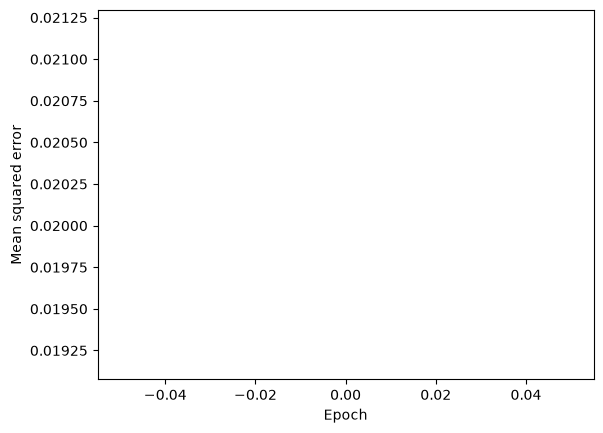

In [14]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('Mean squared error')
plt.xlabel('Epoch')
plt.show()

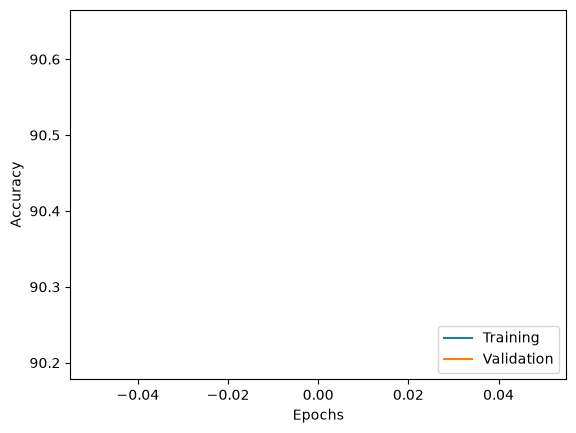

In [15]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc,label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc, label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
plt.show()

In [16]:
test_mse, test_acc = compute_mse_and_acc(model, x_test, y_test)
print(f'Test accuracy: {test_acc*100:.2f}%')

Test accuracy: 90.20%


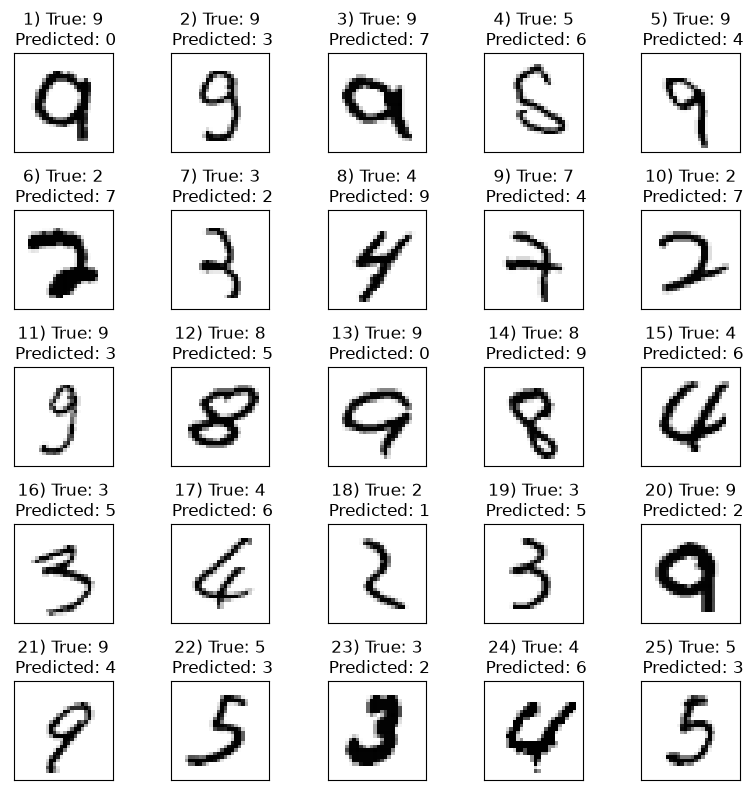

In [17]:
x_test_subset = x_test[:1000, :]
y_test_subset = y_test[:1000]
_, probas = model.forward(x_test_subset)
test_pred = np.argmax(probas, axis=1)
misclassified_images = x_test_subset[y_test_subset != test_pred][:25]
misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]
fig, ax = plt.subplots(nrows=5, ncols=5,sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_title(f'{i+1}) '
                    f'True: {correct_labels[i]}\n'
                    f' Predicted: {misclassified_labels[i]}')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()